# Timoshenko Element: Verification Against the Analytical Solution and GCI Mesh Convergence

**Case:** `uniform_shafts / point_load / case_radial_single_position`
**Study type:** code and solution verification
**Status:** provisional — GCI thresholds to be confirmed

## Questions

1. How far is the Timoshenko FEM solution on the minimal mesh from the
   exact solution of the same equations?
2. Which mesh is required for the quantities of interest — the maximum
   resultant deflection and the absolute deviation of the resultant
   bending moment — to be converged, according to the Grid Convergence
   Index (GCI)?
3. Does the GCI estimate actually bound the true discretisation error?
   This can be checked here because the exact solution is known.

## Verification vs. validation

*Verification* establishes that the code solves the equations of the
model correctly; *validation* establishes that the model represents
reality adequately (ASME V&V 10; Roache, 1998). This notebook addresses
verification only: the reference is the exact solution of the same
equations.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import analytical_solution as an
import case_definition as cd
import figures as fg
from axisforge.results.convergence_results.convergence_results import ConvergenceRecord
from axisforge.solvers.machine_elements.shaft.fem_solvers.global_solver.rigid_support import (
    RigidSupportFEMSolver,
)
from axisforge.solvers.machine_elements.shaft.fem_solvers.submodel_solver.lagrange_multipliers import (
    SubmodelSolver,
)
from axisforge.solvers.mesh.convergence_solver import (
    MeshConvergenceStudy,
    build_mesh_refinement_result,
)

try:
    from axisforge_bridge.outputs.solver_results import convergence_report as crep
except ImportError as exc:  # the bridge must be importable (design-studies root on the path)
    raise ImportError(
        "axisforge_bridge is not importable. Install the design-studies repository "
        "(pip install -e <AxisForge-Design-Studies>) or start Jupyter with "
        "PYTHONPATH=<AxisForge-Design-Studies>."
    ) from exc

fg.use_style()
pd.set_option("display.float_format", lambda v: f"{v:.6g}")

props = cd.section_properties()
system = cd.build_system()
SHAFT = "shaft1"   # shaft2 is its mirror image (see notebook 01)
shaft_sys = next(ss for ss in system.shafts if ss.name == SHAFT)
SETTINGS = cd.THEORIES["timoshenko/cowper"]
KGA = an.kappa_cowper(props.nu) * props.GA
exact = an.solve_shaft(shaft_sys, props.EI, KGA)

## 1. Reference solution

Macaulay's method (`analytical_solution.py`), applied per bending plane,
with every point force $F_k$ at $x_k$ (applied loads and reactions):

$$ M(x) = \sum_k F_k \langle x - x_k\rangle, \qquad
   V(x) = -\frac{dM}{dx}, $$

$$ v(x) = \underbrace{\frac{1}{EI}\sum_k F_k\frac{\langle x-x_k\rangle^3}{6}}_{\text{bending}}
        \;\underbrace{-\;\frac{1}{\kappa GA}\sum_k F_k\langle x-x_k\rangle}_{\text{shear}}
        + C_1 x + C_2, $$

with $C_1, C_2$ determined from $v(x_A) = v(x_B) = 0$.

The shear term carries a negative sign because the shear strain is
$\gamma = v_s' = V/\kappa GA$ with $V = -dM/dx$, hence $v_s = -M/\kappa GA$
(plus linear terms). The shear deflection therefore always adds to the
bending deflection: a Timoshenko beam is never stiffer than the
corresponding Euler–Bernoulli beam.

## 2. Timoshenko on the minimal mesh vs. the analytical solution

In [2]:
base = cd.solve(system, SETTINGS)[SHAFT]          # minimal mesh: mandatory nodes only
x = np.asarray(base.x)
xd = np.linspace(0.0, cd.SHAFT_LENGTH_MM, 2001)

def rel_max_err(fem, ref):
    return float(np.max(np.abs(np.asarray(fem) - ref)) / np.max(np.abs(ref)))

pd.DataFrame(
    {"FEM (minimal mesh)": [len(base.x_nodes), base.v_max, base.M_max],
     "analytical": [np.nan, float(np.max(exact.v(xd))), float(np.max(exact.M(xd)))]},
    index=["nodes", "v_res,max / mm", "M_res,max / N·mm"],
).assign(**{"max. nodal error / max|ref|": [np.nan, rel_max_err(base.v, exact.v(x)),
                                             rel_max_err(base.M, exact.M(x))]})

,FEM (minimal mesh),analytical,max. nodal error / max|ref|
nodes,12,NaN,NaN
"v_res,max / mm",0.341319,0.376339,0.0973623
"M_res,max / N·mm",218245,227734,0.419444


The FEM curve joins the nodal values with straight lines, which is the
displacement field of the two-node linear element itself (exact per bending
plane; for the resultant it is a close approximation). The lower panel shows
the deviation of that interpolated field from the exact solution along the
whole shaft, with the nodal values marked.

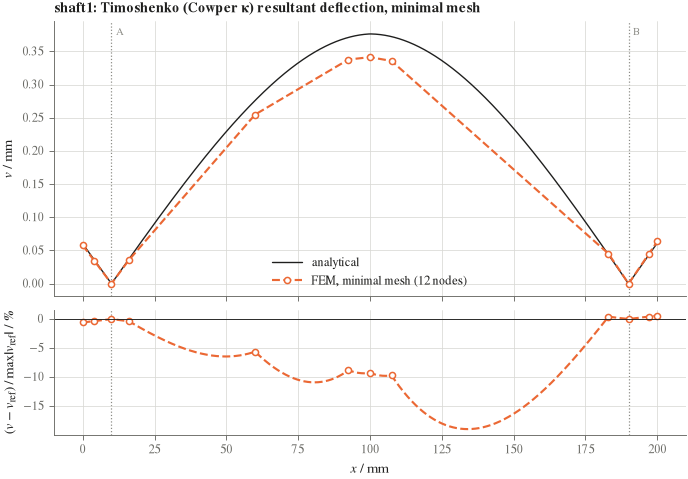

In [3]:
v_fem_xd = np.interp(xd, x, base.v)           # linear-element interpolation between nodes
scale = np.max(exact.v(xd))
fig_base = fg.field_comparison(
    [fg.Series(label="analytical", x=xd, y=exact.v(xd), color="#1f1f1e", linestyle="-",
               kwargs=dict(linewidth=0.9)),
     fg.Series(label=f"FEM, minimal mesh ({len(base.x_nodes)} nodes)", x=x, y=base.v,
               color="#eb6834", linestyle="--", marker="o")],
    [fg.Series(label="", x=xd, y=100 * (v_fem_xd - exact.v(xd)) / scale,
               color="#eb6834", linestyle="--"),
     fg.Series(label="", x=x, y=100 * (np.asarray(base.v) - exact.v(x)) / scale,
               color="#eb6834", linestyle="none", marker="o")],
    title=f"{SHAFT}: Timoshenko (Cowper κ) resultant deflection, minimal mesh",
    ylabel=r"$v$ / mm",
    delta_label=r"$(v - v_\mathrm{ref})\,/\,\max|v_\mathrm{ref}|$ / %",
    supports=(cd.BALL_POSITION_MM, cd.ROLLER_POSITION_MM), support_names=("A", "B"),
)

## 3. GCI mesh convergence study

### 3.1 Procedure

The convergence study uses the AxisForge machinery unchanged:

- **Domain:** the supported span $[x_A, x_B] = [10, 190]$ mm, solved as a
  submodel (`SubmodelSolver`), with the displacements and rotations of the
  minimal-mesh global solution prescribed at the two cut nodes.
- **Refinement:** `Grader` bisects every element of the base mesh at each
  grade (`grade_0` = base nodes in the span, `grade_k` = $2^k$ times as many
  elements), so the refinement ratio is constant, $r = 2$.
- **Quantities of interest** (evaluation forms of `convergence_solver.py`),
  computed on the resultant fields
  $v_\mathrm{res} = \sqrt{v_{xy}^2 + v_{xz}^2}$ and
  $M_\mathrm{res} = \sqrt{M_{xy}^2 + M_{xz}^2}$:
    - `v_res:max` — maximum resultant deflection;
    - `M_res:max_minus_mean` — absolute deviation between the maximum and
      the mean of the resultant moment over the span (robust to the shift of
      the moment peak between grades);
    - `M_res:max` — maximum resultant moment (included because, unlike the
      deviation, its exact value is known).
- **GCI** (Roache, 1998), for three consecutive grades $c, m, f$:

$$ p = \frac{\ln\!\left[(f_c - f_m)/(f_m - f_f)\right]}{\ln r}, \qquad
   \mathrm{GCI}_{fm} = \frac{F_s\,|e_{fm}|}{r^p - 1}, \qquad
   e_{fm} = \frac{f_f - f_m}{f_m}. $$

A quantity is converged when $\mathrm{GCI}_{fm}$ and $\mathrm{GCI}_{mc}$ are
both below the threshold.

`SubmodelResult` has no resultant fields, so a thin read-only adapter
exposes `v_res` and `M_res` to `MeshConvergenceStudy`; nothing in AxisForge
is modified.

In [4]:
# --- GCI parameters (to be confirmed by the author) -------------------------
V_REQUESTS = [("v_res", "max")]
M_REQUESTS = [("M_res", "max_minus_mean"), ("M_res", "max")]
V_GCI_THRESHOLD, V_SAFETY_FACTOR = 0.01, 1.25   # 1 %, Fs = 1.25 (asymptotic range)
M_GCI_THRESHOLD, M_SAFETY_FACTOR = 0.02, 3.0    # 2 %, Fs = 3.0  (conservative)
MAX_LEVELS = 6   # grade_0 ... grade_5; finer grades collide with MESH_MIN_NODE_DIST_MM


class ResultantView:
    """Read-only view of a SubmodelResult adding the resultant fields."""

    def __init__(self, result):
        self._r = result
        self.x_nodes = result.x_nodes
        self.v_res = np.hypot(result.v_xz, result.v_xy)
        self.M_res = np.hypot(result.M_xz, result.M_xy)

    def __getattr__(self, name):
        return getattr(self._r, name)


x_lo, x_hi = sorted(b.position for b in shaft_sys.bearings)
submodel = SubmodelSolver(x_lo, x_hi)

v_study = MeshConvergenceStudy(V_REQUESTS, gci_threshold=V_GCI_THRESHOLD,
                               safety_factor=V_SAFETY_FACTOR)
m_study = MeshConvergenceStudy(M_REQUESTS, gci_threshold=M_GCI_THRESHOLD,
                               safety_factor=M_SAFETY_FACTOR)
v_rec = v_study.new_record("span_v_res", x_lo, x_hi)
m_rec = m_study.new_record("span_M_res", x_lo, x_hi)

grades: dict[str, ResultantView] = {}
for level in range(MAX_LEVELS):
    grade = f"grade_{level}"
    grades[grade] = ResultantView(submodel.solve(base, shaft_sys, SETTINGS, grade))
    if not v_rec.converged:
        v_study.add_level(v_rec, grade, grades[grade])
    if not m_rec.converged:
        m_study.add_level(m_rec, grade, grades[grade])
    if v_rec.converged and m_rec.converged:
        break

last = grades[grade]
for rec, study in ((v_rec, v_study), (m_rec, m_study)):
    if not rec.converged:
        study.finalize_unconverged(rec, last)

refinement = build_mesh_refinement_result(SHAFT, {v_rec.label: v_rec, m_rec.label: m_rec})

### 3.2 GCI results — deflection

In [5]:
print(crep.interval_block(v_rec))

  Interval 'span_v_res'  [10.000, 190.000] mm  -- CONVERGED
    final mesh: 57 node(s)

level    v_res:max [mm]  GCI_v_res:max
-------  --------------  -------------
grade_0  0.3413191283    --           
grade_1  0.3677845572    --           
grade_2  0.3742121111    0.700739%    
grade_3  0.3758084822    0.176200%    

  Richardson GCI detail (per transition, per metric):
transition                 metric     unit  r         p         delta_m_c  delta_f_m  e_m_c      e_f_m      GCI_m_c    GCI_f_m    f_h0          converged
-------------------------  ---------  ----  --------  --------  ---------  ---------  ---------  ---------  ---------  ---------  ------------  ---------
grade_0->grade_1->grade_2  v_res:max  mm    2.000000  2.041767  2.647e-02  6.428e-03  7.753866%  1.747641%  3.109012%  0.700739%  0.3762738791  False    
grade_1->grade_2->grade_3  v_res:max  mm    2.000000  2.009474  6.428e-03  1.596e-03  1.747641%  0.426595%  0.721843%  0.176200%  0.3763359722  True     

  Rich

### 3.3 GCI results — bending moment

In [6]:
print(crep.interval_block(m_rec))

  Interval 'span_M_res'  [10.000, 190.000] mm  -- CONVERGED
    final mesh: 113 node(s)

level    M_res:max_minus_mean [N.mm]  M_res:max [N.mm]   GCI_M_res:max_minus_mean  GCI_M_res:max
-------  ---------------------------  -----------------  ------------------------  -------------
grade_0  118477.8572944658            218245.0583962723  --                        --           
grade_1  117137.6309899567            223180.6837118134  --                        --           
grade_2  115538.8918935320            225479.1512095545  n/a                       2.692807%    
grade_3  114804.2522527663            226609.2314688592  1.621728%                 1.454275%    
grade_4  114445.0893694587            227171.9345337986  0.897766%                 0.738806%    

  Richardson GCI detail (per transition, per metric):
transition                 metric                unit  r         p         delta_m_c   delta_f_m   e_m_c       e_f_m       GCI_m_c    GCI_f_m    f_h0               converged
---

## 4. Does the GCI bound the true error?

For each quantity with a known exact value, the true relative error of the
fine grade, $|f_f - f_\mathrm{exact}|/|f_\mathrm{exact}|$, is compared with
the GCI estimate $\mathrm{GCI}_{fm}$ of the same transition, and the
Richardson-extrapolated value $f_{h0}$ is compared with the exact value.

**Richardson extrapolation.** Assuming $f(h) = f_0 + C\,h^p$ in the asymptotic
range, the three grades give the mesh-independent estimate from the finest
pair:

$$ f_{h0} = f_f + \frac{f_f - f_m}{r^p - 1}. $$

**Admissibility.** The GCI and $f_{h0}$ are defined only for $p > 0$. A
transition with $0 < (f_c - f_m)/(f_m - f_f) \le 1$ (differences between grades
not decreasing) has $p \le 0$, is outside the asymptotic range and is reported
as `n/a`, not converged — this is the case for the first
`M_res:max_minus_mean` transition in Section 3.3.

In [7]:
exact_values = {
    "v_res:max": float(np.max(exact.v(np.linspace(x_lo, x_hi, 180_001)))),
    "M_res:max": float(np.max(exact.M(np.linspace(x_lo, x_hi, 180_001)))),
}
rows = []
for rec in (v_rec, m_rec):
    for i, gci_dict in enumerate(rec.gci_history):
        f_c, f_m, f_f = (rec.point_metrics_history[i + k] for k in range(3))
        for name, gci in gci_dict.items():
            if name not in exact_values or not hasattr(gci, "p"):
                continue
            f_ex = exact_values[name]
            rows.append({
                "metric": name,
                "transition": f"{rec.levels[i]}→{rec.levels[i + 2]}",
                "p": gci.p,
                "GCI_fm / %": 100 * gci.GCI_f_m,
                "true error f_f / %": 100 * abs(f_f[name] - f_ex) / abs(f_ex),
                "GCI bounds error": 100 * gci.GCI_f_m >= 100 * abs(f_f[name] - f_ex) / abs(f_ex),
                "f_h0 (Richardson)": gci.f_h0,
                "exact": f_ex,
                "f_h0 error / %": 100 * abs(gci.f_h0 - f_ex) / abs(f_ex),
            })
gci_check = pd.DataFrame(rows)
gci_check

,metric,transition,p,GCI_fm / %,true error f_f / %,GCI bounds error,f_h0 (Richardson),exact,f_h0 error / %
0,v_res:max,grade_0→grade_2,2.04177,0.700739,0.565256,True,0.376274,0.376339,0.0174076
1,v_res:max,grade_1→grade_3,2.00947,0.1762,0.141072,True,0.376336,0.376339,0.000908413
2,M_res:max,grade_0→grade_2,1.10256,2.69281,0.990113,True,227482,227734,0.110457
3,M_res:max,grade_1→grade_3,1.02425,1.45428,0.493884,True,227702,227734,0.0139256
4,M_res:max,grade_2→grade_4,1.00598,0.738806,0.246796,True,227730,227734,0.00174414


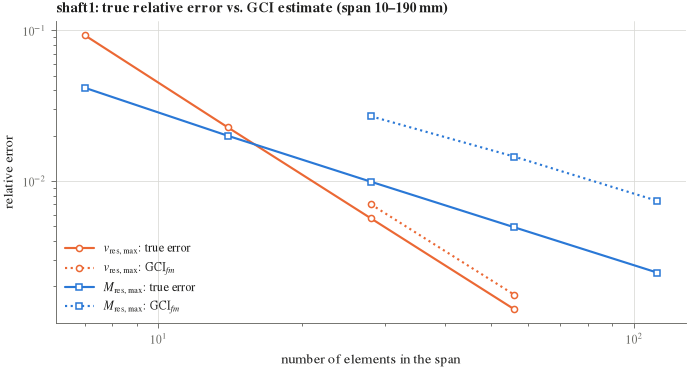

In [8]:
def true_error_series(rec, name, label, color, ls, marker):
    n_el = [len(grades[g].x_nodes) - 1 for g in rec.levels]
    err = [abs(h[name] - exact_values[name]) / exact_values[name] for h in rec.point_metrics_history]
    return fg.Series(label=label, x=n_el, y=err, color=color, linestyle=ls, marker=marker)

def gci_series(rec, name, label, color, ls, marker):
    n_el = [len(grades[g].x_nodes) - 1 for g in rec.levels[2:]]
    gci = [g[name].GCI_f_m for g in rec.gci_history]
    return fg.Series(label=label, x=n_el, y=gci, color=color, linestyle=ls, marker=marker)

fig_gci = fg.convergence(
    [len(grades[g].x_nodes) - 1 for g in m_rec.levels],
    [true_error_series(v_rec, "v_res:max", r"$v_\mathrm{res,max}$: true error", "#eb6834", "-", "o"),
     gci_series(v_rec, "v_res:max", r"$v_\mathrm{res,max}$: GCI$_{fm}$", "#eb6834", ":", "o"),
     true_error_series(m_rec, "M_res:max", r"$M_\mathrm{res,max}$: true error", "#2a78d6", "-", "s"),
     gci_series(m_rec, "M_res:max", r"$M_\mathrm{res,max}$: GCI$_{fm}$", "#2a78d6", ":", "s")],
    title=f"{SHAFT}: true relative error vs. GCI estimate (span {x_lo:.0f}–{x_hi:.0f} mm)",
    ylabel="relative error",
    xlabel=r"number of elements in the span",
    reference_orders={},
)
_ = fig_gci.axes[0].legend(loc="lower left")

## 5. Production solve on the converged mesh

The converged node sets of both records are merged
(`MeshRefinementResult.all_extra_nodes`) and the whole shaft is re-solved
with them as extra mandatory nodes.

In [9]:
extra = refinement.all_extra_nodes
converged = RigidSupportFEMSolver(SETTINGS).solve(shaft_sys, extra_mandatory=extra)
eb = cd.solve(system, cd.THEORIES["euler_bernoulli"])[SHAFT]   # nodally exact on any mesh
xc = np.asarray(converged.x)

summary = pd.DataFrame(
    {"minimal mesh": [len(base.x_nodes), base.v_max, base.M_max,
                      rel_max_err(base.v, exact.v(x))],
     "converged mesh": [len(converged.x_nodes), converged.v_max, converged.M_max,
                        rel_max_err(converged.v, exact.v(xc))],
     "analytical": [np.nan, exact_values["v_res:max"], exact_values["M_res:max"], np.nan]},
    index=["nodes", "v_res,max / mm", "M_res,max / N·mm", "max. nodal error in v / max|v|"],
)
summary

,minimal mesh,converged mesh,analytical
nodes,12,117,NaN
"v_res,max / mm",0.341319,0.376203,0.376339
"M_res,max / N·mm",218245,227141,227734
max. nodal error in v / max|v|,0.0973623,0.000380322,NaN


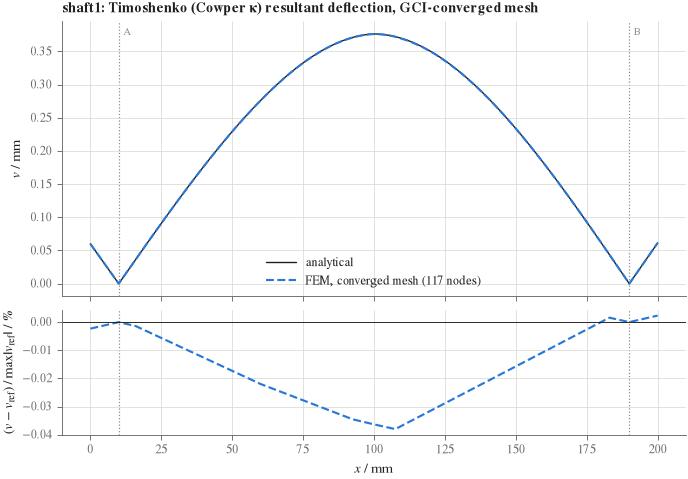

In [10]:
fig_conv = fg.field_comparison(
    [fg.Series(label="analytical", x=xd, y=exact.v(xd), color="#1f1f1e", linestyle="-",
               kwargs=dict(linewidth=0.9)),
     fg.Series(label=f"FEM, converged mesh ({len(converged.x_nodes)} nodes)", x=xc,
               y=converged.v, color="#2a78d6", linestyle="--")],
    [fg.Series(label="", x=xc, y=100 * (np.asarray(converged.v) - exact.v(xc)) / np.max(exact.v(xd)),
               color="#2a78d6", linestyle="--")],
    title=f"{SHAFT}: Timoshenko (Cowper κ) resultant deflection, GCI-converged mesh",
    ylabel=r"$v$ / mm",
    delta_label=r"$(v - v_\mathrm{ref})\,/\,\max|v_\mathrm{ref}|$ / %",
    supports=(cd.BALL_POSITION_MM, cd.ROLLER_POSITION_MM), support_names=("A", "B"),
)

## 6. Conclusions

In [11]:
def last_gci(rec, name):
    return rec.gci_history[-1][name]

shear_effect = 100 * (converged.v_max / eb.v_max - 1)
v_gci = last_gci(v_rec, "v_res:max")
m_gci = last_gci(m_rec, "M_res:max_minus_mean")
bounded = bool(gci_check["GCI bounds error"].all())
display(Markdown(f"""
1. On the minimal mesh ({len(base.x_nodes)} nodes) the Timoshenko deflection deviates from
   the exact solution by **{100 * rel_max_err(base.v, exact.v(x)):.1f} %**.
2. `v_res:max` converged at **{v_rec.levels[-1]}** (GCI$_{{fm}}$ = {100 * v_gci.GCI_f_m:.3f} %,
   observed order p = {v_gci.p:.2f}, theoretical 2); `M_res:max_minus_mean` converged at
   **{m_rec.levels[-1]}** (GCI$_{{fm}}$ = {100 * m_gci.GCI_f_m:.3f} %, p = {m_gci.p:.2f},
   theoretical 1). Status: v {'converged' if v_rec.converged else 'NOT converged'},
   M {'converged' if m_rec.converged else 'NOT converged'}.
3. The GCI estimate {'bounds' if bounded else 'does **not** always bound'} the true error
   for every transition with a known exact value (Section 4).
4. On the converged mesh ({len(converged.x_nodes)} nodes) the deflection error drops to
   **{100 * rel_max_err(converged.v, exact.v(xc)):.3f} %**, and the shear effect relative to
   Euler–Bernoulli is **{shear_effect:+.2f} %**, matching the closed-form value.
5. The Richardson-extrapolated values agree with the exact ones to within
   {gci_check['f_h0 error / %'].max():.3f} % (Section 4).
"""))


1. On the minimal mesh (12 nodes) the Timoshenko deflection deviates from
   the exact solution by **9.7 %**.
2. `v_res:max` converged at **grade_3** (GCI$_{fm}$ = 0.176 %,
   observed order p = 2.01, theoretical 2); `M_res:max_minus_mean` converged at
   **grade_4** (GCI$_{fm}$ = 0.898 %, p = 1.03,
   theoretical 1). Status: v converged,
   M converged.
3. The GCI estimate bounds the true error
   for every transition with a known exact value (Section 4).
4. On the converged mesh (117 nodes) the deflection error drops to
   **0.038 %**, and the shear effect relative to
   Euler–Bernoulli is **+2.73 %**, matching the closed-form value.
5. The Richardson-extrapolated values agree with the exact ones to within
   0.110 % (Section 4).


## References

- ASME V&V 10-2019, *Standard for Verification and Validation in
  Computational Solid Mechanics*.
- Roache, P. J. (1998). *Verification and Validation in Computational
  Science and Engineering*. Hermosa Publishers — GCI and Richardson
  extrapolation.
- Celik, I. B. et al. (2008). Procedure for estimation and reporting of
  uncertainty due to discretization in CFD applications. *J. Fluids Eng.*
  130(7), 078001.
- Cowper (1966); Hutchinson (2001) — see notebook 01.